# Task 2: Credit Risk Prediction
**DevelopersHub Corporation | Data Science & Analytics Internship**

# **By: Muhammad Yahya Imran**

---

**Objective:** Predict whether a loan applicant is likely to default on a loan.

**Dataset:** Loan Prediction Dataset (Kaggle)

**Steps:** Data Loading → Cleaning → EDA → Model Training → Evaluation → Conclusion

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset from Kaggle

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download('altruistdelhite04/loan-prediction-problem-dataset')
print('Dataset downloaded to:', path)

# List all files to find the correct filename
files = os.listdir(path)
print('Files in dataset:', files)

# Automatically load the correct CSV file
csv_file = os.path.join(path, [f for f in files if f.endswith('.csv') and 'train' in f.lower()][0])
print('Loading:', csv_file)
df = pd.read_csv(csv_file)

print('Dataset Shape:', df.shape)
df.head(10)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Dataset downloaded to: /kaggle/input/loan-prediction-problem-dataset
Files in dataset: ['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']
Loading: /kaggle/input/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv
Dataset Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## Step 3: Dataset Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
# Inspect for any missing entries
print('Missing values:')
print(df.isnull().sum())

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

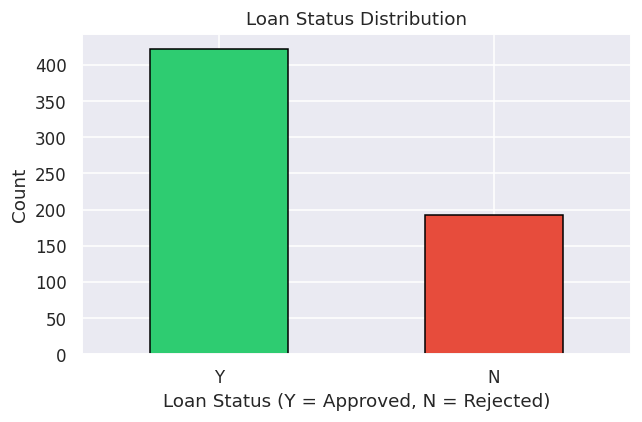

In [7]:
# Plot the breakdown of approved vs rejected loans
plt.figure(figsize=(6, 4))
df['Loan_Status'].value_counts().plot(kind='bar', color=['#2ECC71', '#E74C3C'], edgecolor='black')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

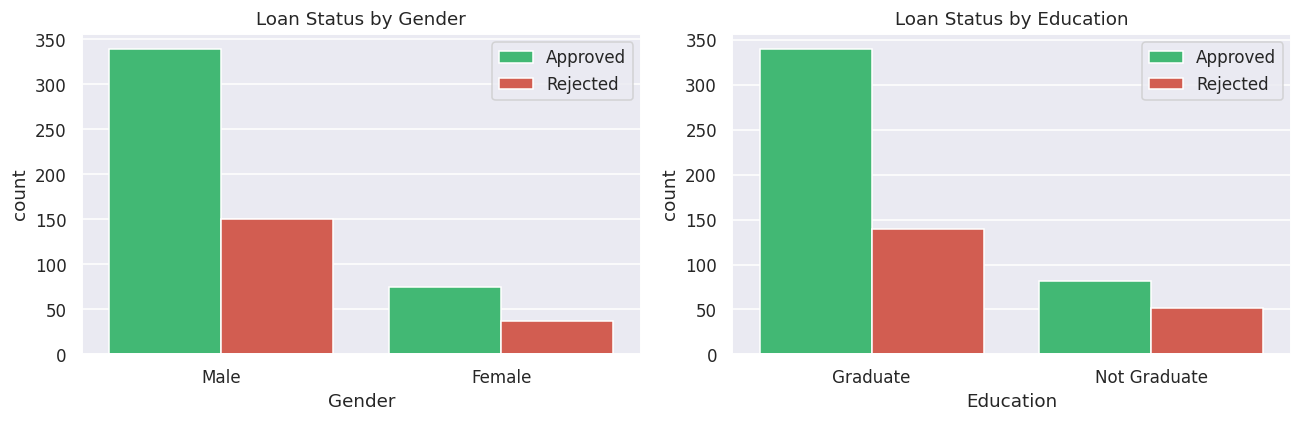

In [9]:
# Compare approval rates across gender and education groups
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Gender', hue='Loan_Status', ax=axes[0],
              palette={'Y': '#2ECC71', 'N': '#E74C3C'})
axes[0].set_title('Loan Status by Gender')
axes[0].legend(['Approved', 'Rejected'])

sns.countplot(data=df, x='Education', hue='Loan_Status', ax=axes[1],
              palette={'Y': '#2ECC71', 'N': '#E74C3C'})
axes[1].set_title('Loan Status by Education')
axes[1].legend(['Approved', 'Rejected'])

plt.tight_layout()
plt.show()

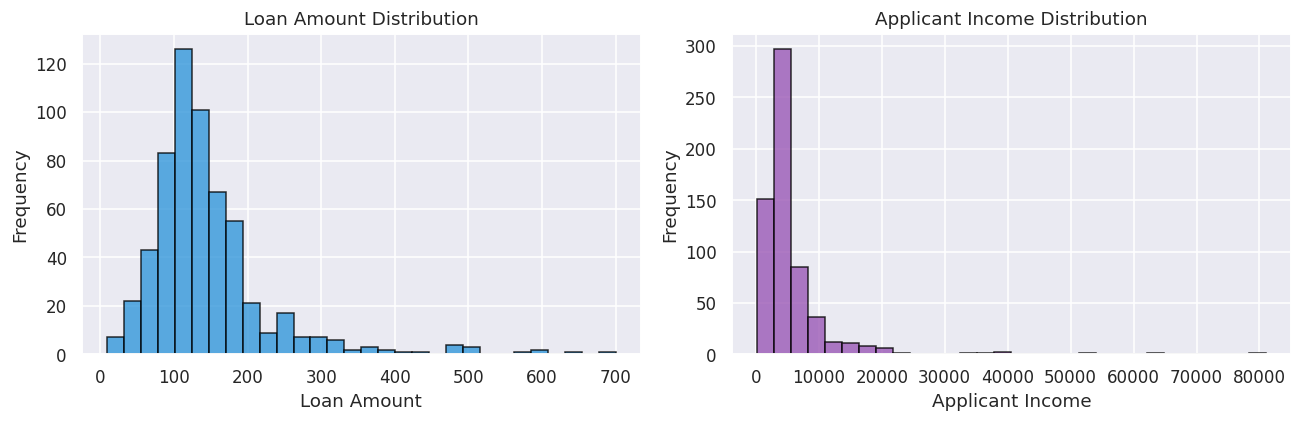

In [10]:
# Visualize spread of loan amounts and applicant income
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['LoanAmount'].dropna(), bins=30, color='#3498DB', edgecolor='black', alpha=0.8)
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['ApplicantIncome'].dropna(), bins=30, color='#9B59B6', edgecolor='black', alpha=0.8)
axes[1].set_title('Applicant Income Distribution')
axes[1].set_xlabel('Applicant Income')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

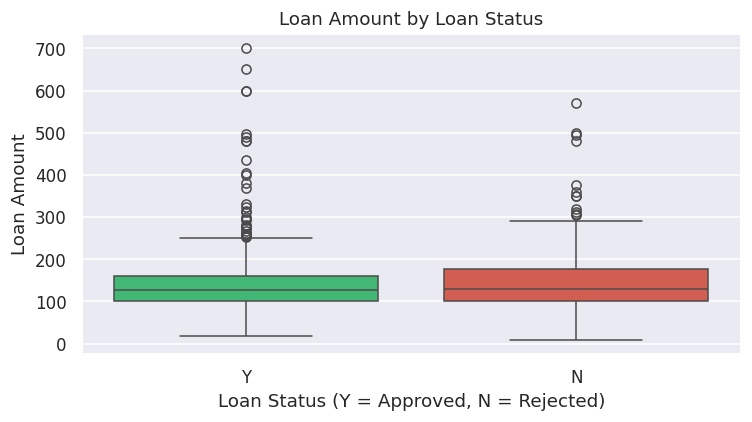

In [11]:
# Box plot of loan amounts segmented by approval outcome
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount',
            palette={'Y': '#2ECC71', 'N': '#E74C3C'})
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

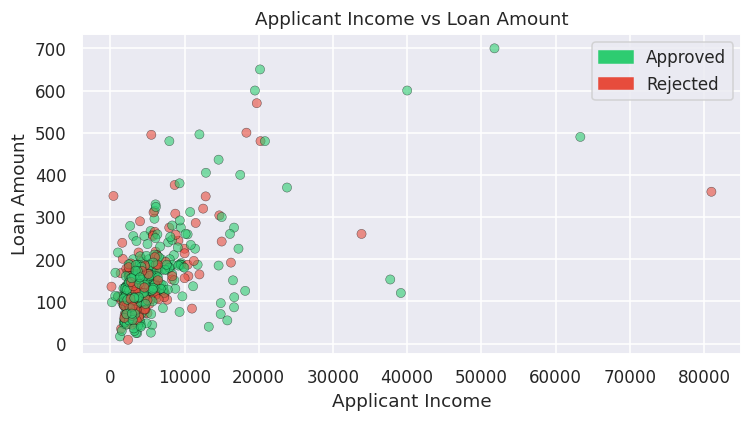

In [12]:
# Scatter plot relating income to requested loan amount
plt.figure(figsize=(7, 4))
colors = df['Loan_Status'].map({'Y': '#2ECC71', 'N': '#E74C3C'})
plt.scatter(df['ApplicantIncome'], df['LoanAmount'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.3)
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#2ECC71', label='Approved'), Patch(color='#E74C3C', label='Rejected')])
plt.tight_layout()
plt.show()

## Step 5: Data Cleaning & Preprocessing

In [13]:
df_clean = df.copy()

# Remove Loan_ID — it carries no predictive information
df_clean.drop(columns=['Loan_ID'], inplace=True)

# Impute missing entries using appropriate strategies
# Categorical fields → fill with the most frequent value
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Numerical: fill with median
df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median(), inplace=True)

print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [14]:
# Apply label encoding to convert text columns to numbers
le = LabelEncoder()
cat_encode_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_encode_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print('Encoding complete.')
df_clean.head()

Encoding complete.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


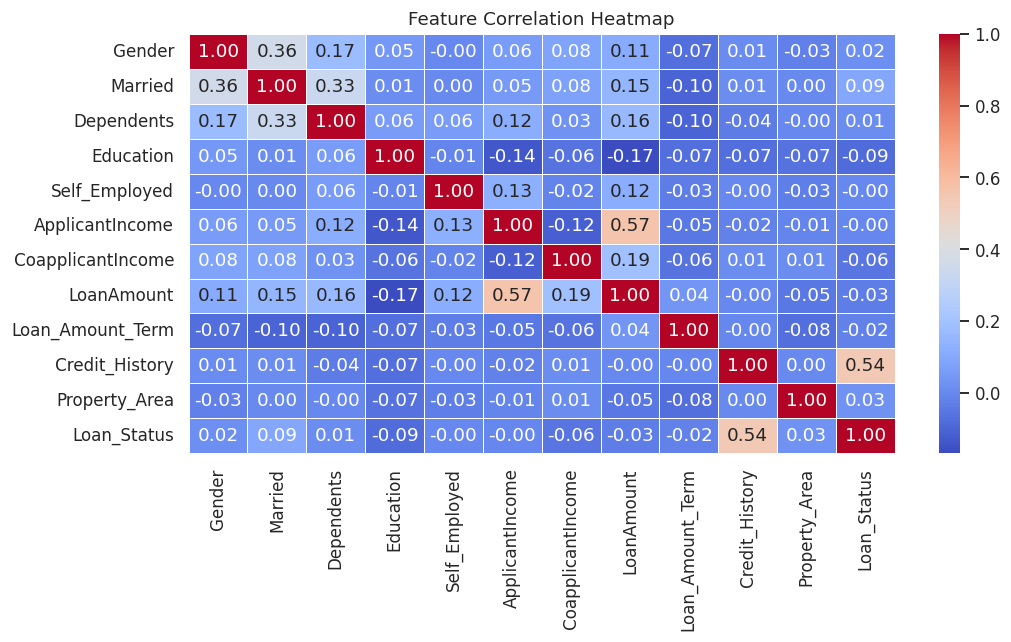

In [15]:
# Heatmap of pairwise feature correlations after encoding
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
# Separate input features from the prediction target
X = df_clean.drop(columns=['Loan_Status'])
y = df_clean['Loan_Status']

# Partition data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalise features using standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 491
Testing samples : 123


## Step 6: Model Training

In [17]:
# Train Logistic Regression as the baseline classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print('Logistic Regression')
print('Accuracy:', round(lr_acc, 4))

Logistic Regression
Accuracy: 0.8618


In [18]:
# Train a Decision Tree for comparison
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_acc  = accuracy_score(y_test, dt_pred)

print('Decision Tree')
print('Accuracy:', round(dt_acc, 4))

Decision Tree
Accuracy: 0.7642


## Step 7: Model Evaluation

In [19]:
# Detailed per-class performance reports
print('===== Logistic Regression =====')
print(classification_report(y_test, lr_pred, target_names=['Rejected', 'Approved']))

print('===== Decision Tree =====')
print(classification_report(y_test, dt_pred, target_names=['Rejected', 'Approved']))

===== Logistic Regression =====
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

===== Decision Tree =====
              precision    recall  f1-score   support

    Rejected       0.62      0.61      0.61        38
    Approved       0.83      0.84      0.83        85

    accuracy                           0.76       123
   macro avg       0.72      0.72      0.72       123
weighted avg       0.76      0.76      0.76       123



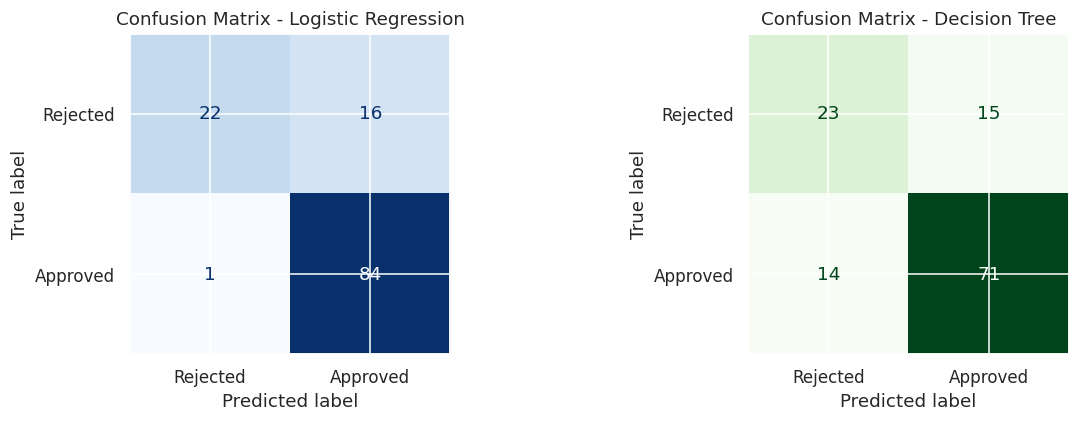

In [20]:
# Side-by-side confusion matrices for model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred),
    display_labels=['Rejected', 'Approved']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, dt_pred),
    display_labels=['Rejected', 'Approved']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Decision Tree')

plt.tight_layout()
plt.show()

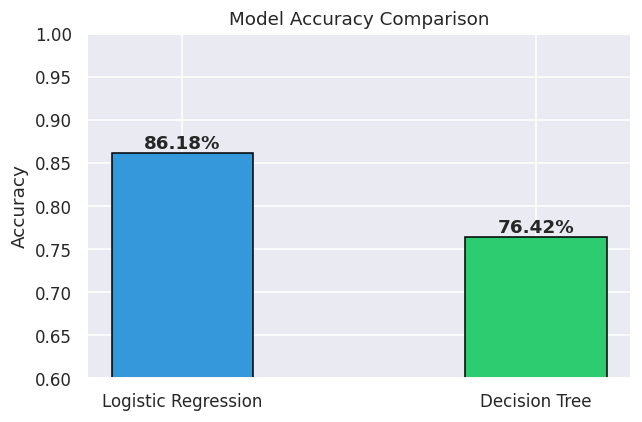

In [21]:
# Visual comparison of model accuracies
plt.figure(figsize=(6, 4))
models     = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_acc, dt_acc]
bars = plt.bar(models, accuracies, color=['#3498DB', '#2ECC71'], edgecolor='black', width=0.4)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Conclusion

In [22]:
best = 'Logistic Regression' if lr_acc >= dt_acc else 'Decision Tree'
best_acc = max(lr_acc, dt_acc)

print('Model Comparison:')
comparison = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [round(lr_acc, 4), round(dt_acc, 4)]
})
print(comparison.to_string(index=False))

print(f'\nBetter Model: {best} with accuracy of {best_acc:.2%}')
print('\nKey Findings:')
print('  - Credit history is the most influential feature for loan approval.')
print('  - Graduates have a higher loan approval rate than non-graduates.')
print('  - Applicants with higher income tend to get higher loan amounts approved.')
print('  - Missing values were handled using mode for categorical and median for numerical columns.')

Model Comparison:
              Model  Accuracy
Logistic Regression    0.8618
      Decision Tree    0.7642

Better Model: Logistic Regression with accuracy of 86.18%

Key Findings:
  - Credit history is the most influential feature for loan approval.
  - Graduates have a higher loan approval rate than non-graduates.
  - Applicants with higher income tend to get higher loan amounts approved.
  - Missing values were handled using mode for categorical and median for numerical columns.
